# Logistic Regression — Binary Classification

**Objective:** Predict whether a company's CEO is **Male or Female** using all available features.

**Target variable:** `CEO_Gender` (Male / Female)

**Approach:**
1. Load & split data
2. Create binary label from `CEO_Gender`
3. Impute + encode features (excluding `CEO_Gender`)
4. Handle class imbalance with `class_weight='balanced'`
5. Fit logistic regression
6. Evaluate with confusion matrix + classification report

In [21]:
import pandas as pd
import numpy as np

security_df = pd.read_csv('security_data_10000.csv')
security_df.head()

,Sector,CEO_Gender,Size,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,Sec_Rating,CEO_Sec_Exp,LOT_in_Business,Stock_Market
0,Hospitality,Male,Large,186,80,38,High,High,11,No
1,Hospitality,Female,Large,229,72,42,Medium,Medium,21,Yes
2,Hospitality,Male,Small,108,78,35,High,Medium,15,Yes
3,Hospitality,Male,Large,210,70,35,Medium,Low,14,No
4,Banking,Male,Small,34,19,3,Low,High,3,No


In [22]:
from sklearn.model_selection import train_test_split

security_df_train, security_df_test = train_test_split(security_df, test_size=0.2, random_state=42)

print('Train:', security_df_train.shape)
print('Test: ', security_df_test.shape)

Train: (8000, 10)
Test:  (2000, 10)


## Step 1 — Create Binary Label
We predict whether the CEO is **Male** (True) or **Female** (False).

In [23]:
security_df_train_labels = (security_df_train['CEO_Gender'] == 'Male')
security_df_test_labels  = (security_df_test['CEO_Gender'] == 'Male')

print('Train label distribution:')
print(security_df_train_labels.value_counts())
print(security_df_train_labels.value_counts(normalize=True).round(2))

Train label distribution:
CEO_Gender
True     5162
False    2838
Name: count, dtype: int64
CEO_Gender
True     0.65
False    0.35
Name: proportion, dtype: float64


## Step 2 — Prepare Features
Drop `CEO_Gender` — it is the target, not a feature.

In [24]:
security_df_train = security_df_train.drop('CEO_Gender', axis=1)
security_df_test  = security_df_test.drop('CEO_Gender', axis=1)

## Step 3 — Impute Numeric Features
Fit imputer on train only, transform both train and test.

In [25]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

security_df_train_num = security_df_train.select_dtypes(include=[np.number])
security_df_test_num  = security_df_test.select_dtypes(include=[np.number])

imputer.fit(security_df_train_num)

security_df_train_tf = pd.DataFrame(imputer.transform(security_df_train_num),
                                     columns=security_df_train_num.columns,
                                     index=security_df_train_num.index)

security_df_test_tf  = pd.DataFrame(imputer.transform(security_df_test_num),
                                     columns=security_df_test_num.columns,
                                     index=security_df_test_num.index)

## Step 4 — Encode Categorical Features
`CEO_Gender` is excluded — it is the target variable.

In [26]:
cat_cols = ['Sector', 'Size', 'Sec_Rating', 'CEO_Sec_Exp', 'Stock_Market']

security_df_train_cat = pd.get_dummies(security_df_train[cat_cols], dtype=int)
security_df_test_cat  = pd.get_dummies(security_df_test[cat_cols],  dtype=int)

security_df_train_final = pd.concat([security_df_train_tf, security_df_train_cat], axis=1)
security_df_test_final  = pd.concat([security_df_test_tf,  security_df_test_cat],  axis=1)

print('Final train shape:', security_df_train_final.shape)
print('Final test shape: ', security_df_test_final.shape)

Final train shape: (8000, 18)
Final test shape:  (2000, 18)


## Step 5 — Scale Features
Logistic regression is sensitive to feature scale. Fit scaler on train only.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(security_df_train_final)

security_df_train_scaled = scaler.transform(security_df_train_final)
security_df_test_scaled  = scaler.transform(security_df_test_final)

## Step 6 — Fit Logistic Regression
`class_weight='balanced'` corrects for class imbalance automatically.

In [28]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(security_df_train_scaled, security_df_train_labels)

train_predictions = log_reg.predict(security_df_train_scaled)
test_predictions  = log_reg.predict(security_df_test_scaled)

## Step 7 — Evaluate
Confusion matrix and classification report on both train and test.

In [29]:
from sklearn.metrics import confusion_matrix, classification_report

print('Confusion Matrix - Train:')
print(confusion_matrix(security_df_train_labels, train_predictions))
print('\nClassification Report - Train:')
print(classification_report(security_df_train_labels, train_predictions, target_names=['Female', 'Male']))

print('\n---\n')

print('Confusion Matrix - Test:')
print(confusion_matrix(security_df_test_labels, test_predictions))
print('\nClassification Report - Test:')
print(classification_report(security_df_test_labels, test_predictions, target_names=['Female', 'Male']))

Confusion Matrix - Train:
[[1469 1369]
 [2536 2626]]

Classification Report - Train:
              precision    recall  f1-score   support

      Female       0.37      0.52      0.43      2838
        Male       0.66      0.51      0.57      5162

    accuracy                           0.51      8000
   macro avg       0.51      0.51      0.50      8000
weighted avg       0.55      0.51      0.52      8000


---

Confusion Matrix - Test:
[[363 335]
 [644 658]]

Classification Report - Test:
              precision    recall  f1-score   support

      Female       0.36      0.52      0.43       698
        Male       0.66      0.51      0.57      1302

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.56      0.51      0.52      2000



## Step 8 — Visualise Confusion Matrix

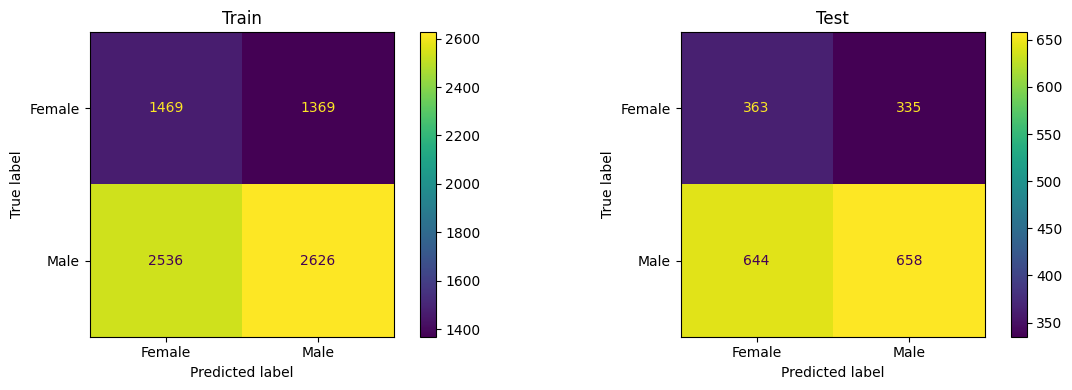

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(security_df_train_labels, train_predictions,
                                         display_labels=['Female', 'Male'], ax=axes[0])
axes[0].set_title('Train')

ConfusionMatrixDisplay.from_predictions(security_df_test_labels, test_predictions,
                                         display_labels=['Female', 'Male'], ax=axes[1])
axes[1].set_title('Test')

plt.tight_layout()
plt.show()